In [ ]:
!pip install fer
from fer.fer import FER
import cv2
from google.colab import files  # Only for Colab
import matplotlib.pyplot as plt
import numpy as np


Saving expression.jpg to expression (3).jpg


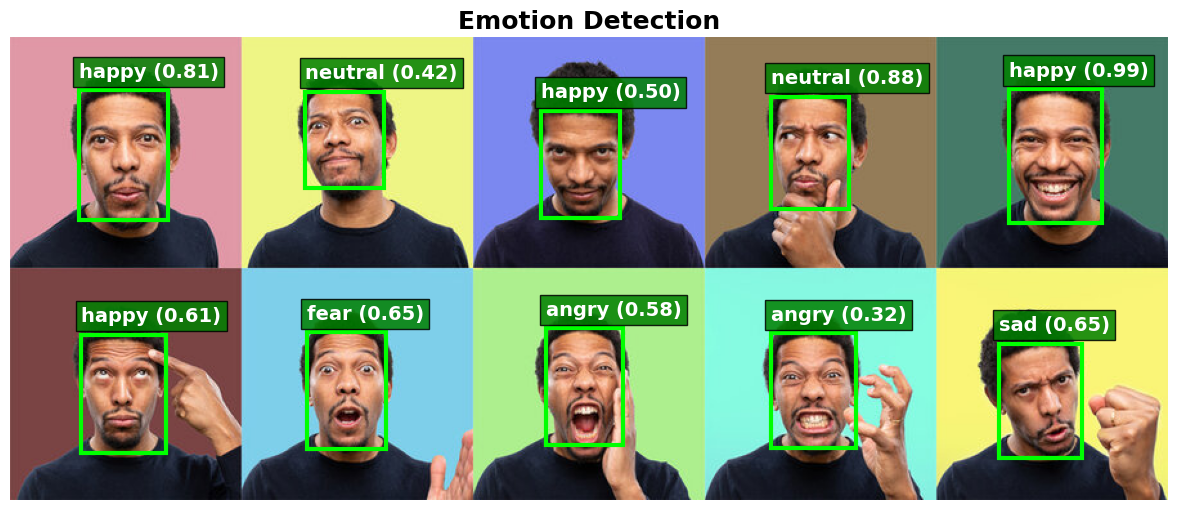

In [ ]:
# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # Get uploaded filename

# Read image
# The error "(-215:Assertion failed) !_src.empty()" indicates cv2.imread failed.
# This often happens with unsupported formats like AVIF.
# Use PIL to read the image bytes and convert to numpy array.
from PIL import Image
import io
import matplotlib.patches as patches # Import patches for drawing rectangles

image_bytes = uploaded[image_path]
pil_image = Image.open(io.BytesIO(image_bytes))

# Convert PIL Image (which is typically RGB) to a NumPy array.
# Ensure it's not RGBA if it was read that way (e.g., from some PNGs).
image_np = np.array(pil_image)
if image_np.shape[2] == 4:
    image_np = cv2.cvtColor(image_np, cv2.COLOR_RGBA2RGB)

# The FER detector expects RGB images.
image_rgb = image_np

# Initialize FER detector
detector = FER(mtcnn=True)

# Detect emotions
results = detector.detect_emotions(image_rgb)

# Set up matplotlib figure and axes
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image_rgb)

# Draw bounding boxes and labels using matplotlib
for face in results:
    x, y, w, h = face["box"]
    emotion, score = detector.top_emotion(image_rgb[y:y+h, x:x+w])

    # Draw rectangle
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)

    # Add text label
    ax.text(
        x, y - 10, f"{emotion} ({score:.2f})",
        color='white', fontsize=14, fontweight='bold',
        bbox=dict(facecolor='green', alpha=0.85, pad=4)
    )

ax.axis('off')
plt.title("Emotion Detection", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()